# Exploratory Data Analysis (EDA)

This notebook contains visualizations and analysis of the student performance dataset. It is used to understand the distribution of various features, and how they correlate with student grades and pass/fail rates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = os.path.join("..", "data", "student_performance.csv")

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000000, 6)


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


## 1. Distribution of Target Variables
Visualizing the grade distribution and pass/fail metrics.

/var/folders/md/jy599zp14t10wjrh_6_ymbvw0000gn/T/ipykernel_19583/3658950319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="grade", order=["A", "B", "C", "D", "E", "F"], palette="viridis", ax=ax[0])
/var/folders/md/jy599zp14t10wjrh_6_ymbvw0000gn/T/ipykernel_19583/3658950319.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="pass_fail", palette="Set2", ax=ax[1])


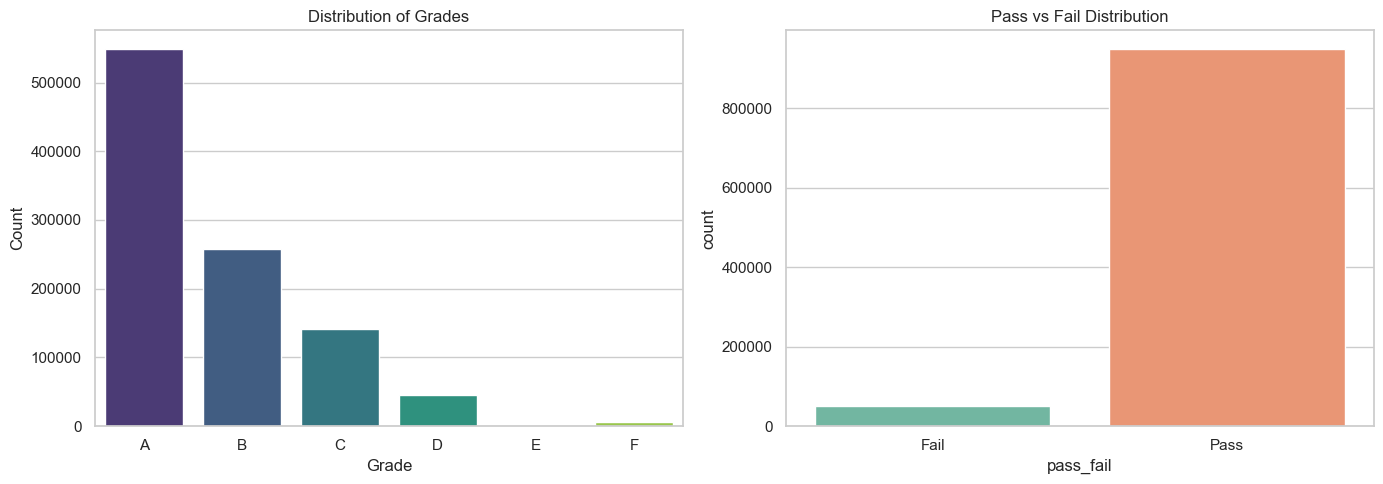

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Grade Distribution
sns.countplot(data=df, x="grade", order=["A", "B", "C", "D", "E", "F"], palette="viridis", ax=ax[0])
ax[0].set_title("Distribution of Grades")
ax[0].set_xlabel("Grade")
ax[0].set_ylabel("Count")

df["pass_fail"] = df["grade"].apply(lambda x: 1 if x in ["A", "B", "C"] else 0)

# Pass/Fail Distribution
sns.countplot(data=df, x="pass_fail", palette="Set2", ax=ax[1])
ax[1].set_title("Pass vs Fail Distribution")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["Fail", "Pass"])

plt.tight_layout()
plt.show()

## 2. Feature Distributions
Checking out the core predictive features.

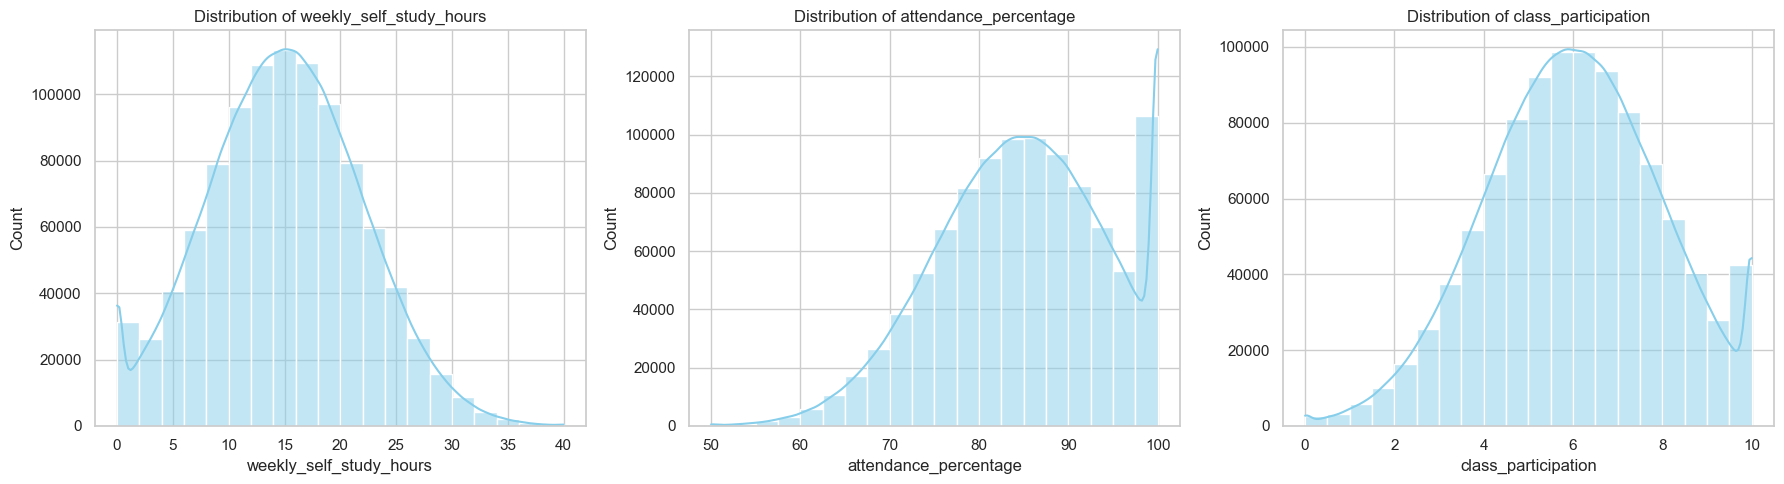

In [3]:
features = ["weekly_self_study_hours", "attendance_percentage", "class_participation"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {feature}")
    
plt.tight_layout()
plt.show()

## 3. Relationships and Correlations
How the features correlate with performance outcomes.

/var/folders/md/jy599zp14t10wjrh_6_ymbvw0000gn/T/ipykernel_19583/2250339951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pass_fail", y=feature, palette="Set2", ax=axes[i])
/var/folders/md/jy599zp14t10wjrh_6_ymbvw0000gn/T/ipykernel_19583/2250339951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pass_fail", y=feature, palette="Set2", ax=axes[i])
/var/folders/md/jy599zp14t10wjrh_6_ymbvw0000gn/T/ipykernel_19583/2250339951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pass_fail", y=feature, pa

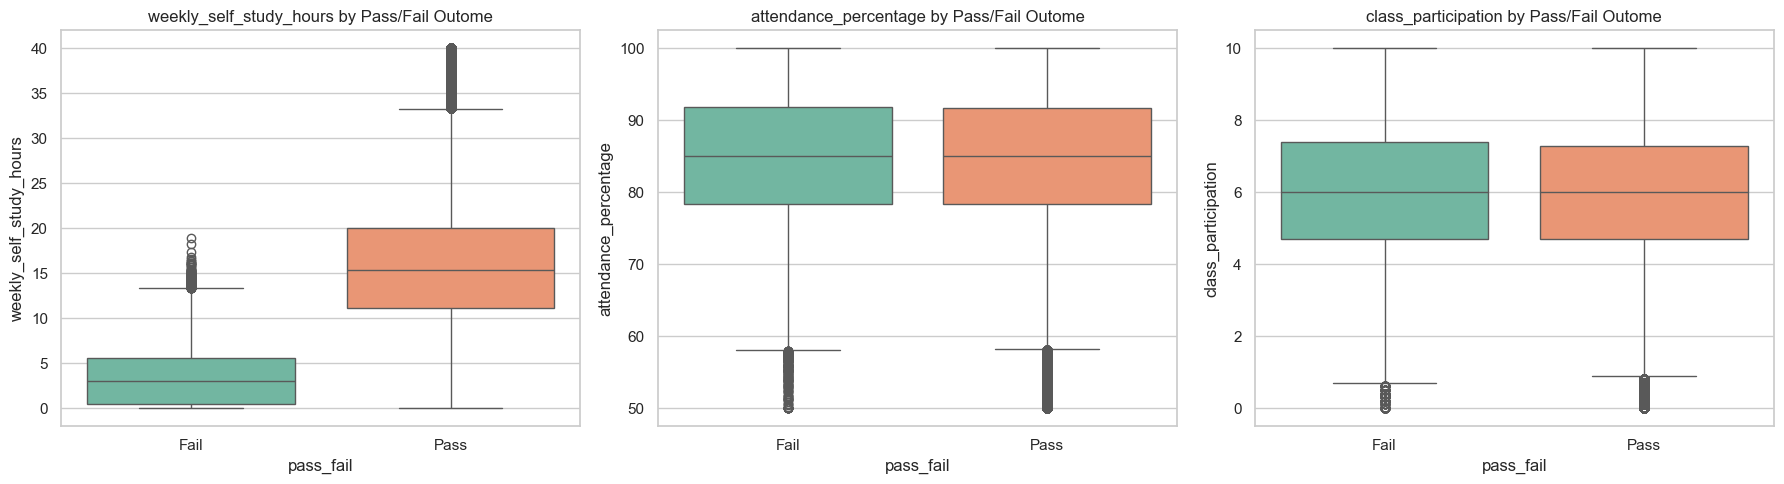

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="pass_fail", y=feature, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{feature} by Pass/Fail Outome")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Fail", "Pass"])

plt.tight_layout()
plt.show()

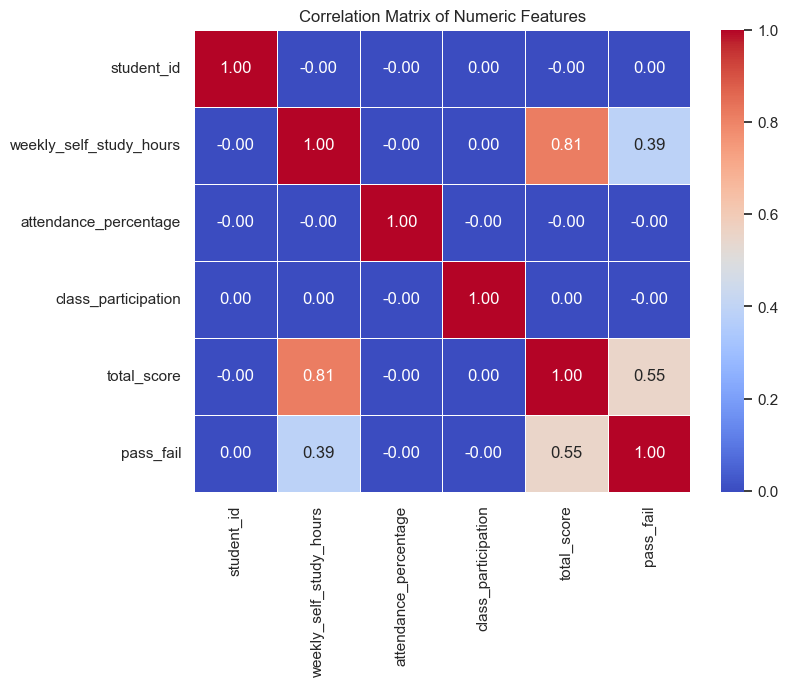

In [5]:
numeric_cols = df.select_dtypes(include=["number"])
corr = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()